In [13]:
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import GridSearchCV

# Grafik-Einstellungen für schöne Plots
plt.style.use('ggplot')

In [14]:
# Da wir im Ordner 'notebooks' sind, müssen wir einen Ordner zurück '..' navigieren
data_path = os.path.join('..', 'data', 'processed', 'model_input', 'training_data.csv')

df = pd.read_csv(data_path)
print(f"Daten geladen! Anzahl historischer Matches: {len(df)}")

features = [
    'Delta_Total_Market_Value', 'Delta_Median_Top11_Value', 'Delta_Chemistry',
    'Delta_Form_Rating', 'Delta_UCL_Minutes', 'Delta_Tournament_Minutes',
    'Delta_Average_Age', 'Delta_TM_Value_Rank', 'Delta_FIFA_Rank', 'Delta_FIFA_Points'
]

X = df[features]
y = df['target']

# Train/Test Split (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Trainingsdaten: {len(X_train)} | Testdaten: {len(X_test)}")

Daten geladen! Anzahl historischer Matches: 914
Trainingsdaten: 731 | Testdaten: 183


In [15]:
param_grid = {
    'max_depth': [3, 5, 7],             # Wie komplex darf das Modell "denken"?
    'learning_rate': [0.01, 0.05, 0.1], # Wie schnell passt es sich an Fehler an?
    'n_estimators': [50, 100, 200],     # Wie viele Entscheidungsbäume baut es?
    'subsample': [0.8, 1.0]             # Wie viel % der Daten sieht ein einzelner Baum? (Gegen Auswendiglernen)
}

# 2. Das Basis-Modell
xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

# 3. Den Such-Algorithmus (Grid Search) aufsetzen
print("Starte Hyperparameter-Tuning... (Das dauert jetzt kurz, hol dir einen ☕)")
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,       # 5-fache Kreuzvalidierung (Testet jede Kombination 5 Mal anders!)
    n_jobs=-1,  # Nutzt ALLE Kerne deines Computers für maximale Geschwindigkeit
    verbose=1   # Zeigt dir im Terminal, wie viele Fits gemacht werden
)

# 4. Die Suche starten!
grid_search.fit(X_train, y_train)

# 5. Ergebnisse auswerten
print("\n🎉 Tuning abgeschlossen!")
print("Die besten Regler-Einstellungen (Mischpult) sind:")
print(grid_search.best_params_)

# 6. Das beste Modell übernehmen und auf unseren Test-Daten prüfen
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\nNeue Modell-Genauigkeit (Tuned): {accuracy_tuned * 100:.2f}%")

Starte Hyperparameter-Tuning... (Das dauert jetzt kurz, hol dir einen ☕)
Fitting 5 folds for each of 54 candidates, totalling 270 fits

🎉 Tuning abgeschlossen!
Die besten Regler-Einstellungen (Mischpult) sind:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

Neue Modell-Genauigkeit (Tuned): 47.54%


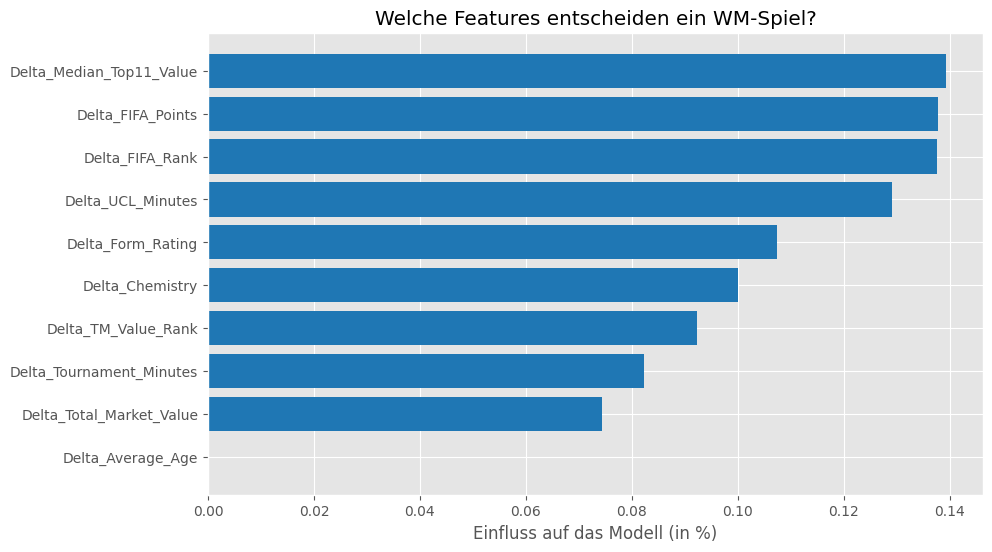

In [16]:
# Wichtigkeit der Features auslesen
importances = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plotten
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#1f77b4')
plt.title('Welche Features entscheiden ein WM-Spiel?')
plt.xlabel('Einfluss auf das Modell (in %)')
plt.show()

In [ ]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'xgboost_wm_modelV3.joblib')
joblib.dump(model, model_path)
print(f"Modell erfolgreich unter '{model_path}' gespeichert!")

Modell erfolgreich unter '..\models\xgboost_wm_modelV2.joblib' gespeichert!
